# Notebook 05 – Exploratory Data Analysis (EDA)

## Objective

### Analyze the engineered customer features to understand customer spending,
### purchase behaviour, website engagement and payment preferences before
### performing customer segmentation.

### Input

#### - customer_features.csv

### Output

#### - Business insights
#### - Feature distributions
#### - Correlation analysis
#### - Outlier detection
#### - Dataset ready for clustering

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path

plt.style.use("ggplot")

In [2]:
PROCESSED= Path("data/processed")
df= pd.read_csv(PROCESSED/"customer_features.csv")

In [3]:
print("Rows:",df.shape[0])
print("Columns:",df.shape[1])

Rows: 16865
Columns: 48


In [4]:
df.head()

,customer_id,name,first_order_date,total_orders,total_revenue,average_order_value,time_to_2nd_purchase,last_purchase_date,city_/_tier,acquisition_channel_(first_touch),...,view_to_cart_rate,cart_to_checkout_rate,checkout_to_purchase_rate,revenue_per_session,preferred_device,preferred_traffic_source,favorite_campaign,customer_lifetime_value,loyalty_score,value_segment
0,CUST-0000001,Tejas Sarkar,2025-09-08,1,3356.0,3356.0,0.0,2025-09-08,Mumbai / Tier 1,Meta,...,0.250000,1.0,1.0,3356.0,mobile,Meta,KS_Sep25_Camp_46,3356.0,1,Medium
1,CUST-0000003,Lila Bedi,2023-09-11,1,2360.0,2360.0,0.0,2023-09-11,Bengaluru / Tier 1,Google,...,0.000000,0.0,0.0,0.0,Unknown,Unknown,Unknown,2360.0,1,Low
2,CUST-0000004,Hamsini Parekh,2022-03-18,2,4029.0,2014.5,449.0,2023-06-11,Hyderabad / Tier 1,Google,...,0.363636,1.0,1.0,2014.5,desktop,Google,KS_AlwaysOn,4029.0,2,Medium
3,CUST-0000005,Yug Gill,2025-10-16,1,2581.0,2581.0,0.0,2025-10-16,Delhi / Tier 1,Offline (Friends/Family),...,0.000000,0.0,0.0,0.0,Unknown,Unknown,Unknown,2581.0,1,Low
4,CUST-0000007,Daksha Ramaswamy,2024-03-11,2,5365.0,2682.5,303.0,2025-01-08,Bengaluru / Tier 1,Meta,...,0.500000,1.0,1.0,2682.5,mobile,Meta,KS_AlwaysOn,5365.0,4,High


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16865 entries, 0 to 16864
Data columns (total 48 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   customer_id                        16865 non-null  object 
 1   name                               16865 non-null  object 
 2   first_order_date                   16865 non-null  object 
 3   total_orders                       16865 non-null  int64  
 4   total_revenue                      16865 non-null  float64
 5   average_order_value                16865 non-null  float64
 6   time_to_2nd_purchase               16865 non-null  float64
 7   last_purchase_date                 16865 non-null  object 
 8   city_/_tier                        16865 non-null  object 
 9   acquisition_channel_(first_touch)  16865 non-null  object 
 10  repurchased                        16865 non-null  int64  
 11  total_spend                        16865 non-null  int

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
total_orders,16865.0,1.778832,1.110665,1.0,1.000000,1.00,2.000000,9.00
total_revenue,16865.0,4506.799704,2952.748135,1350.0,2431.000000,3422.00,5688.000000,25649.00
average_order_value,16865.0,2528.301471,531.041725,1350.0,2150.670000,2518.00,2874.000000,4234.00
time_to_2nd_purchase,16865.0,188.460362,295.750250,0.0,0.000000,0.00,303.000000,1452.00
repurchased,16865.0,0.459413,0.498365,0.0,0.000000,0.00,1.000000,1.00
total_spend,16865.0,4506.799704,2952.748135,1350.0,2431.000000,3422.00,5688.000000,25649.00
avg_spend,16865.0,2528.301471,531.041727,1350.0,2150.666667,2518.00,2874.000000,4234.00
median_spend,16865.0,2524.826949,541.648725,1350.0,2128.000000,2513.00,2884.000000,4234.00
max_spend,16865.0,2739.777587,624.981270,1350.0,2273.000000,2764.00,3205.000000,4246.00
min_spend,16865.0,2321.619152,592.941693,1350.0,1844.000000,2231.00,2724.000000,4234.00


In [7]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round((df.isnull().sum()/len(df))*100,2)
})

missing = missing[missing["Missing Values"]>0]
missing.sort_values("Missing Values",ascending=False)

,Missing Values,Percentage


In [8]:
duplicates = df.duplicated().sum()
print("Duplicate Rows :",duplicates)

Duplicate Rows : 0


In [9]:
numerical= df.select_dtypes(include=np.number)
categorical= df.select_dtypes(include="object")

print("Numerical Features:",numerical.shape[1])
print("Categorical Features:",categorical.shape[1])

Numerical Features: 36
Categorical Features: 12


In [10]:
numerical.columns.tolist()

['total_orders',
 'total_revenue',
 'average_order_value',
 'time_to_2nd_purchase',
 'repurchased',
 'total_spend',
 'avg_spend',
 'median_spend',
 'max_spend',
 'min_spend',
 'gross_revenue',
 'total_discount',
 'avg_discount',
 'avg_discount_percent',
 'total_orders_actual',
 'completed_orders',
 'returned_orders',
 'rto_orders',
 'payment_diversity',
 'category_diversity',
 'size_diversity',
 'color_diversity',
 'vendor_diversity',
 'return_rate',
 'total_sessions',
 'total_product_views',
 'total_add_to_cart',
 'total_checkout',
 'total_purchases',
 'website_revenue',
 'view_to_cart_rate',
 'cart_to_checkout_rate',
 'checkout_to_purchase_rate',
 'revenue_per_session',
 'customer_lifetime_value',
 'loyalty_score']

In [11]:
categorical.columns.tolist()

['customer_id',
 'name',
 'first_order_date',
 'last_purchase_date',
 'city_/_tier',
 'acquisition_channel_(first_touch)',
 'preferred_payment',
 'favorite_category',
 'preferred_device',
 'preferred_traffic_source',
 'favorite_campaign',
 'value_segment']

### Distribution of Numerical Features:

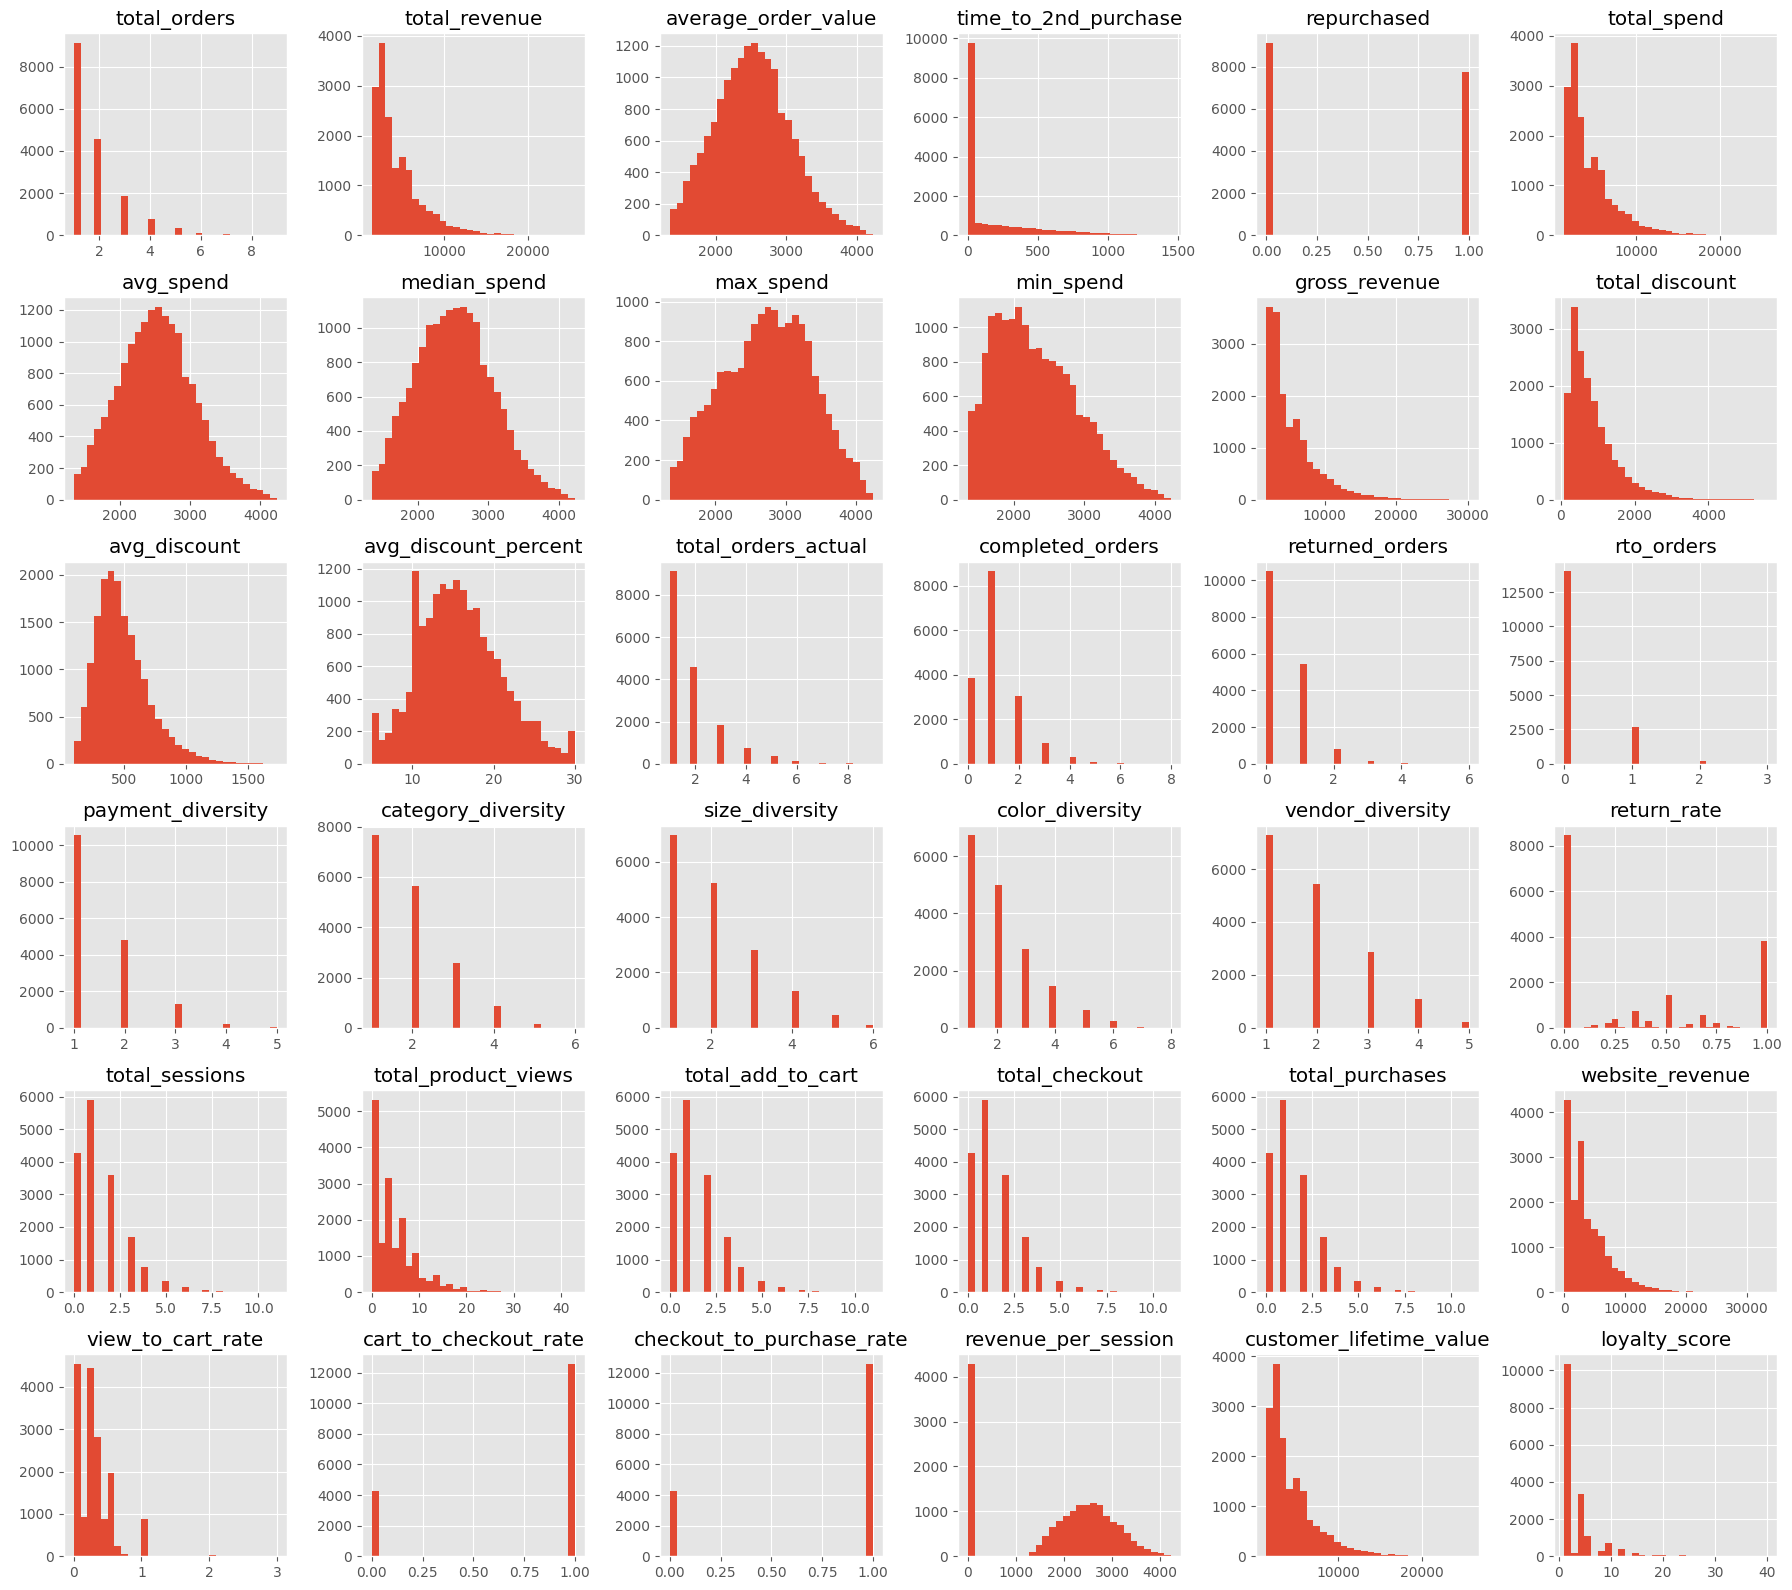

In [12]:
numerical.hist(
    figsize=(18,16),
    bins=30
)
plt.tight_layout()
plt.show()

### Customer revenue distribution:

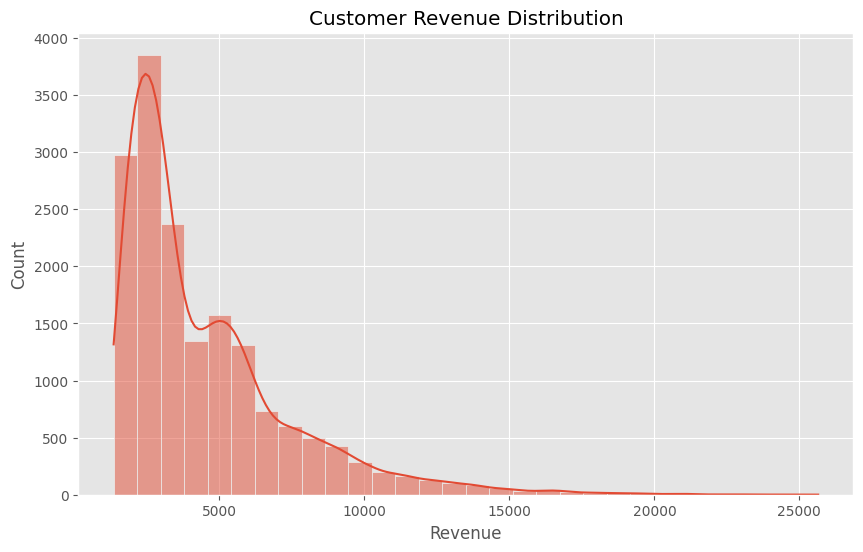

In [13]:
plt.figure(figsize=(10,6))
sns.histplot(
    df["total_revenue"],
    bins=30,
    kde=True
)
plt.title("Customer Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Count")
plt.show()

### Average order value distribution:

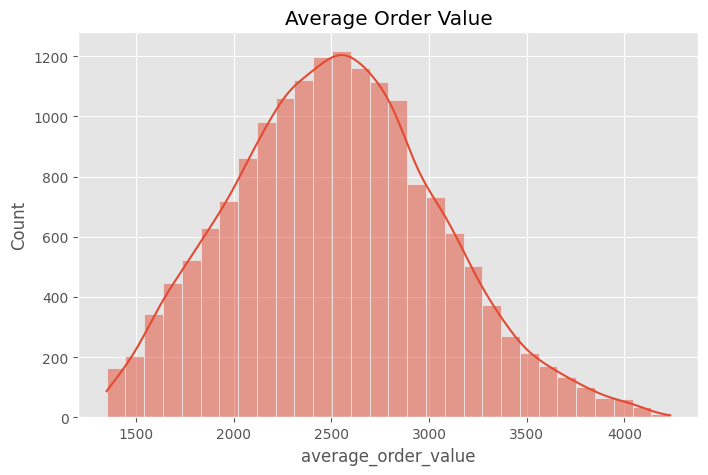

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(
    df["average_order_value"],
    bins=30,
    kde=True
)
plt.title("Average Order Value")
plt.show()

### Customer lifetime value distribution:

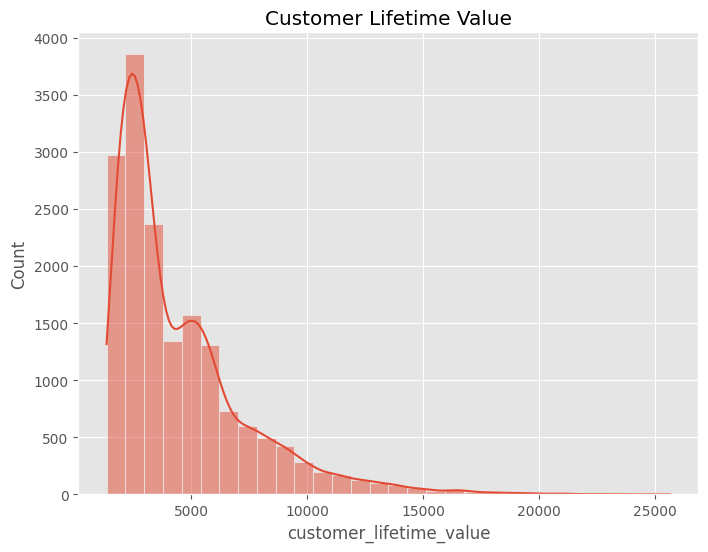

In [15]:
plt.figure(figsize=(8,6))

sns.histplot(
    df["customer_lifetime_value"],
    bins=30,
    kde=True
)
plt.title("Customer Lifetime Value")
plt.show()

### Spending Statistics:

In [16]:
spending = df[[
    "total_revenue",
    "average_order_value",
    "customer_lifetime_value"
]]
spending.describe().T

,count,mean,std,min,25%,50%,75%,max
total_revenue,16865.0,4506.799704,2952.748135,1350.0,2431.00,3422.0,5688.0,25649.00
average_order_value,16865.0,2528.301471,531.041725,1350.0,2150.67,2518.0,2874.0,4234.00
customer_lifetime_value,16865.0,4506.799708,2952.748183,1350.0,2431.00,3422.0,5688.0,25649.01


### Payment Behaviour: Most preferred payment option:

In [17]:
payment_counts= df["preferred_payment"].value_counts()
payment_counts

preferred_payment
Card          5945
UPI           5398
COD           4065
NetBanking     867
Wallet         590
Name: count, dtype: int64

### Preferred payment menthod distribution:

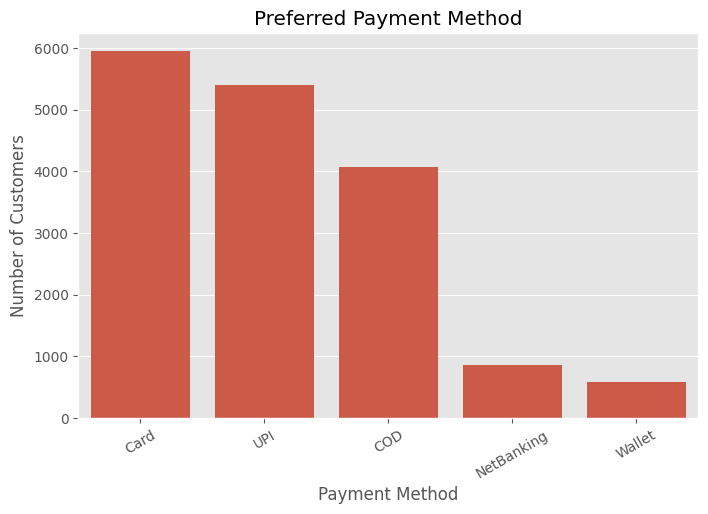

In [18]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x="preferred_payment",
    order=df["preferred_payment"].value_counts().index
)
plt.title("Preferred Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30)
plt.show()

### Payment Diversity

#### -Payment diversity means the number of different payment methods used by a customer.
#### -Higher diversity indicates that the customer is comfortable using multiple payment methods.

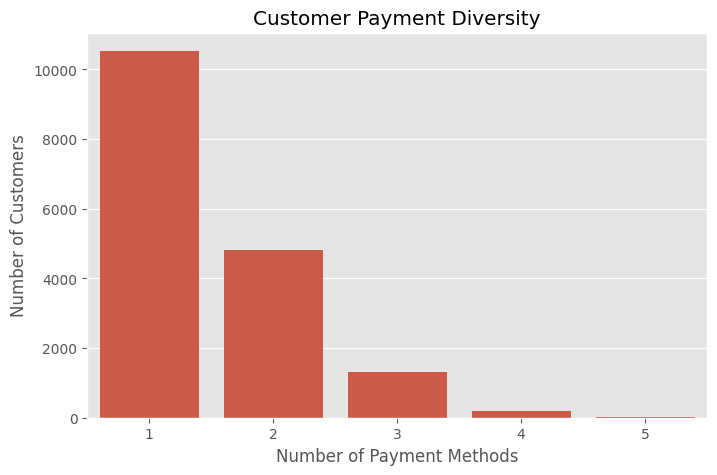

In [19]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x="payment_diversity"
)

plt.title("Customer Payment Diversity")
plt.xlabel("Number of Payment Methods")
plt.ylabel("Number of Customers")
plt.show()

### Repurchase Behaviour

#### -Analyzing the proportion of customers who repurchase items

In [20]:
repurchase_counts= df["repurchased"].value_counts()
print(repurchase_counts)

repurchased
0    9117
1    7748
Name: count, dtype: int64


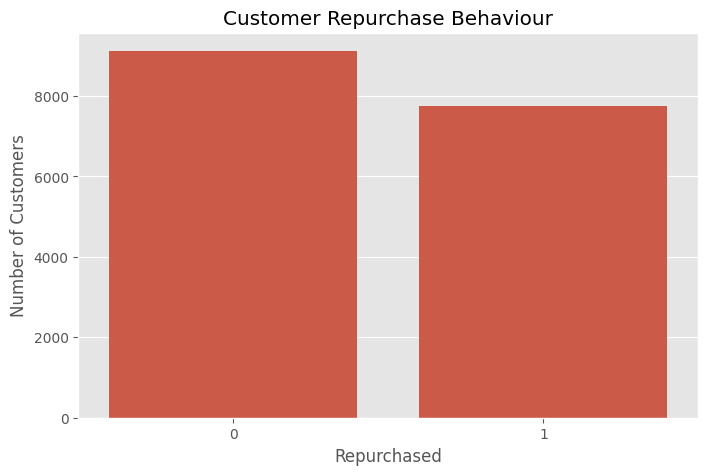

In [21]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x="repurchased"
)

plt.title("Customer Repurchase Behaviour")
plt.xlabel("Repurchased")
plt.ylabel("Number of Customers")
plt.show()

### Order Behaviour

#### -Compare completed, returned and RTO orders to understand customer order outcomes.

In [22]:
order_columns = [
    "completed_orders",
    "returned_orders",
    "rto_orders"
]
order_summary = df[order_columns].sum()
order_summary

completed_orders    19413
returned_orders      7541
rto_orders           3046
dtype: int64

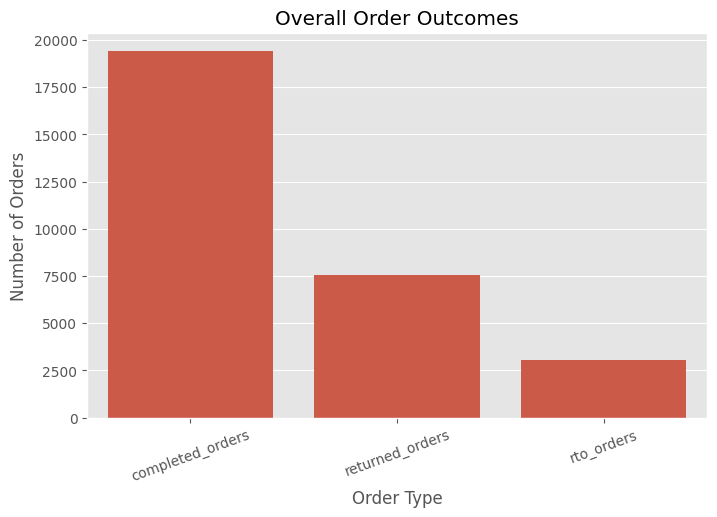

In [23]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=order_summary.index,
    y=order_summary.values
)

plt.title("Overall Order Outcomes")
plt.xlabel("Order Type")
plt.ylabel("Number of Orders")
plt.xticks(rotation=20)
plt.show()

## Geographical Analysis:
### Customer Distribution by City Tier
#### -Analyze how customers are distributed across the available city/tier categories.

In [24]:
city_tier_counts = df["city_/_tier"].value_counts()
city_tier_counts

city_/_tier
Mumbai / Tier 1           1878
Delhi / Tier 1            1574
Bengaluru / Tier 1        1175
Pune / Tier 1              981
Hyderabad / Tier 1         854
Ahmedabad / Tier 1         680
Chennai / Tier 1           655
Lucknow / Tier 2           522
Surat / Tier 2             517
Kolkata / Tier 1           507
Jaipur / Tier 2            506
Noida / Tier 2             501
Indore / Tier 2            499
Gurgaon / Tier 2           490
Patna / Tier 2             377
Coimbatore / Tier 2        371
Kochi / Tier 2             370
Rajkot / Tier 2            364
Chandigarh / Tier 2        364
Kanpur / Tier 2            360
Mysuru / Tier 2            343
Bhopal / Tier 2            342
Dehradun / Tier 2          341
Nagpur / Tier 2            338
Visakhapatnam / Tier 2     332
Nashik / Tier 2            331
Ludhiana / Tier 2          330
Vadodara / Tier 2          325
Ranchi / Tier 2            324
Bhubaneswar / Tier 2       314
Name: count, dtype: int64

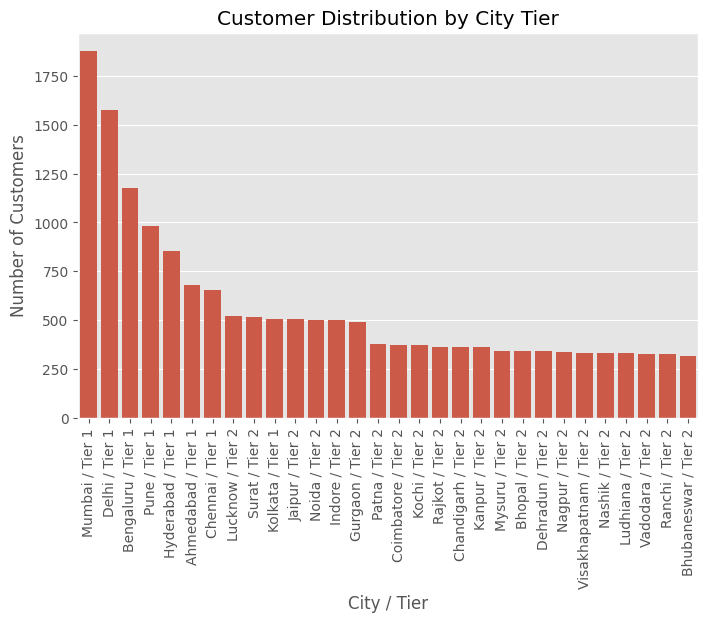

In [25]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="city_/_tier",
    order=df["city_/_tier"].value_counts().index
)

plt.title("Customer Distribution by City Tier")
plt.xlabel("City / Tier")
plt.ylabel("Number of Customers")
plt.xticks(rotation=90)
plt.show()

### Revenue by City Tier
#### Comparing customer revenue across different city/tier groups.

In [26]:
tier_revenue = (
    df.groupby("city_/_tier")["total_revenue"]
    .sum()
    .sort_values(ascending=False)
)

tier_revenue

city_/_tier
Mumbai / Tier 1           8516996.0
Delhi / Tier 1            6929489.0
Bengaluru / Tier 1        5430940.0
Pune / Tier 1             4517064.0
Hyderabad / Tier 1        3926681.0
Ahmedabad / Tier 1        3072276.0
Chennai / Tier 1          2882790.0
Surat / Tier 2            2401074.0
Noida / Tier 2            2278454.0
Lucknow / Tier 2          2245650.0
Kolkata / Tier 1          2244602.0
Indore / Tier 2           2239505.0
Gurgaon / Tier 2          2217398.0
Jaipur / Tier 2           2214111.0
Rajkot / Tier 2           1777198.0
Chandigarh / Tier 2       1753690.0
Patna / Tier 2            1723775.0
Kochi / Tier 2            1617121.0
Coimbatore / Tier 2       1614538.0
Bhopal / Tier 2           1578406.0
Kanpur / Tier 2           1565002.0
Ranchi / Tier 2           1534902.0
Dehradun / Tier 2         1523504.0
Ludhiana / Tier 2         1513850.0
Visakhapatnam / Tier 2    1491306.0
Nashik / Tier 2           1479003.0
Mysuru / Tier 2           1458562.0
Nagpur / Tier 2 

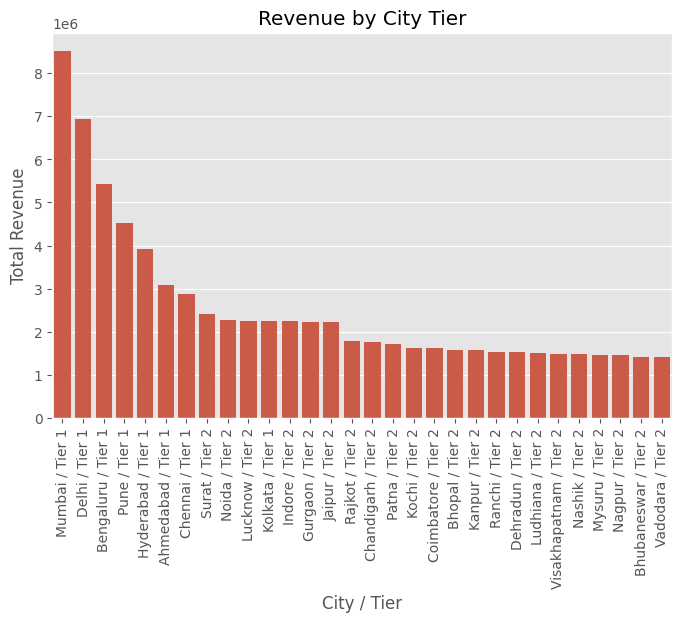

In [27]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=tier_revenue.index,
    y=tier_revenue.values
)

plt.title("Revenue by City Tier")
plt.xlabel("City / Tier")
plt.ylabel("Total Revenue")
plt.xticks(rotation=90)
plt.show()

## Acquisition Analysis:
### Customer Acquisition Channels
#### Analyze which channels were responsible for acquiring customers.

In [28]:
channel_counts=(
    df["acquisition_channel_(first_touch)"].value_counts()
)
channel_counts

acquisition_channel_(first_touch)
Meta                        7307
Google                      2756
Influencer                  2711
Organic Instagram           1247
Email/SMS                   1130
Instagram DM                 865
Offline (Friends/Family)     849
Name: count, dtype: int64

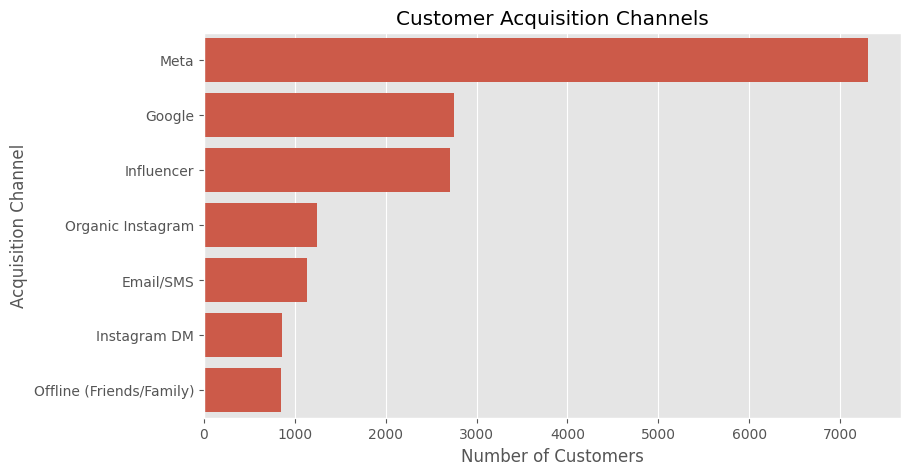

In [29]:
plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    y="acquisition_channel_(first_touch)",
    order=channel_counts.index
)

plt.title("Customer Acquisition Channels")
plt.xlabel("Number of Customers")
plt.ylabel("Acquisition Channel")
plt.show()

### Revenue by Acquisition Channel
#### -Compare the total revenue generated by customers acquired through different channels.

In [30]:
channel_revenue=(
    df.groupby("acquisition_channel_(first_touch)")["total_revenue"]
    .sum()
    .sort_values(ascending=False)
)
channel_revenue

acquisition_channel_(first_touch)
Meta                        32821293.0
Google                      12233663.0
Influencer                  12164481.0
Organic Instagram            5715401.0
Email/SMS                    5145230.0
Instagram DM                 4011422.0
Offline (Friends/Family)     3915687.0
Name: total_revenue, dtype: float64

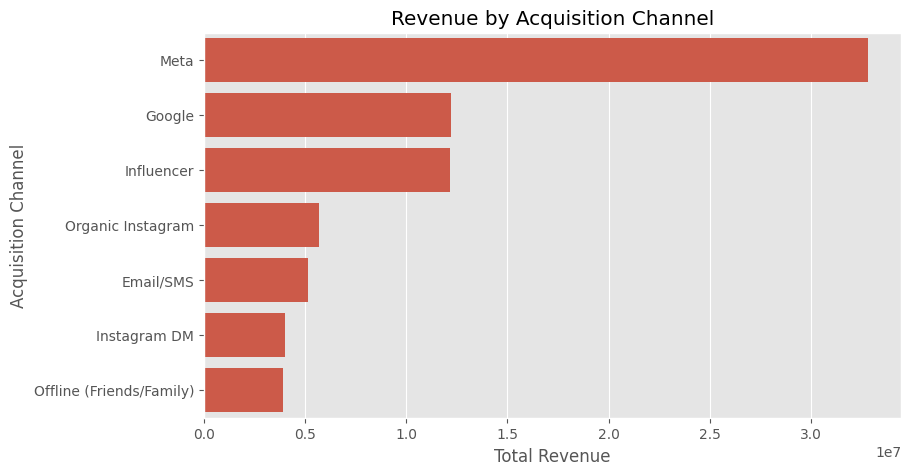

In [31]:
plt.figure(figsize=(9,5))

sns.barplot(
    x=channel_revenue.values,
    y=channel_revenue.index
)

plt.title("Revenue by Acquisition Channel")
plt.xlabel("Total Revenue")
plt.ylabel("Acquisition Channel")
plt.show()

### Favorite Product Categories:
#### -Analyze the most frequently preferred product categories among customers.

In [32]:
category_counts = (
    df["favorite_category"]
    .value_counts()
)
category_counts

favorite_category
shirts      7118
pants       4674
croptops    3117
tshirts      943
jackets      666
shorts       347
Name: count, dtype: int64

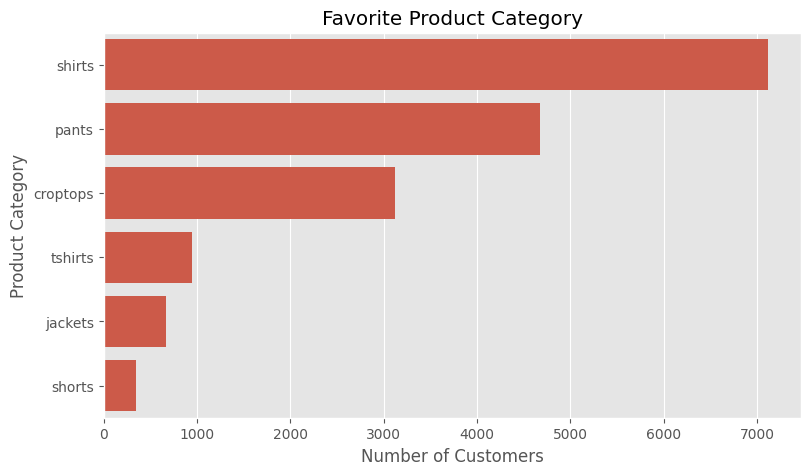

In [33]:
plt.figure(figsize=(9, 5))
sns.countplot(
    data=df,
    y="favorite_category",
    order=category_counts.index
)

plt.title("Favorite Product Category")
plt.xlabel("Number of Customers")
plt.ylabel("Product Category")
plt.show()

### Category Diversity
#### -Category diversity represents the number of different product categories purchased by a customer.

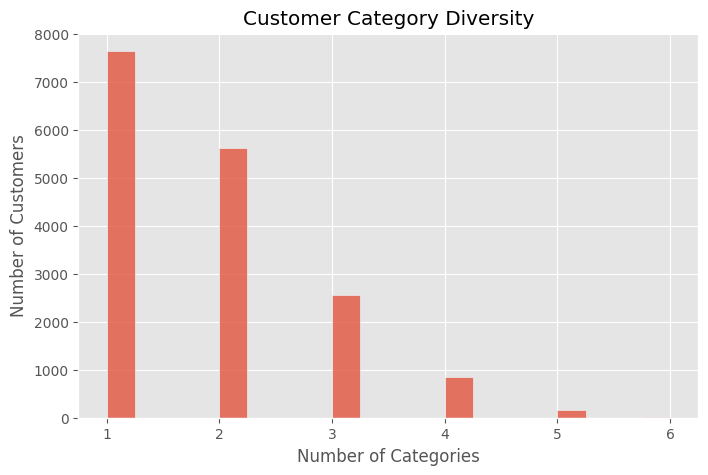

In [34]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="category_diversity",
    bins=20
)

plt.title("Customer Category Diversity")
plt.xlabel("Number of Categories")
plt.ylabel("Number of Customers")

plt.show()

## Return Analysis:

In [35]:
df["return_rate"].describe()

count    16865.000000
mean         0.352020
std          0.410466
min          0.000000
25%          0.000000
50%          0.000000
75%          0.666667
max          1.000000
Name: return_rate, dtype: float64

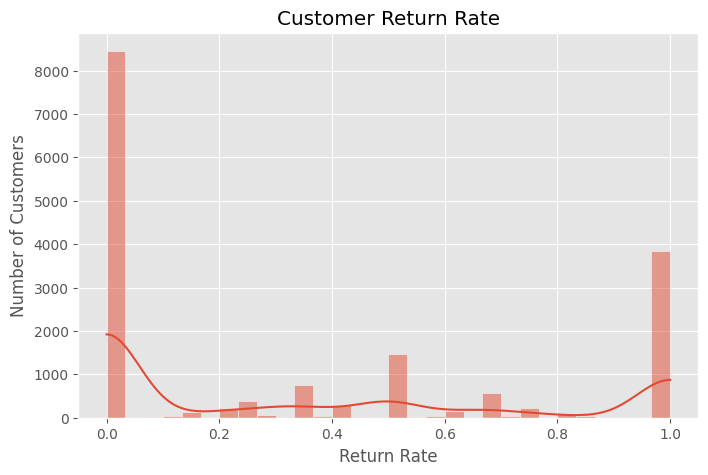

In [36]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="return_rate",
    bins=30,
    kde=True
)

plt.title("Customer Return Rate")
plt.xlabel("Return Rate")
plt.ylabel("Number of Customers")
plt.show()

## Website Behavior:
### Website Engagement

#### -Analyze customer activity on the website, including sessions, product views,
#### -cart additions and purchases.

In [37]:
website_columns = [
    "total_sessions",
    "total_product_views",
    "total_add_to_cart",
    "total_checkout",
    "total_purchases"
]

df[website_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
total_sessions,16865.0,1.468366,1.384966,0.0,0.0,1.0,2.0,11.0
total_product_views,16865.0,4.697006,4.927581,0.0,0.0,4.0,7.0,43.0
total_add_to_cart,16865.0,1.468366,1.384966,0.0,0.0,1.0,2.0,11.0
total_checkout,16865.0,1.468366,1.384966,0.0,0.0,1.0,2.0,11.0
total_purchases,16865.0,1.468366,1.384966,0.0,0.0,1.0,2.0,11.0


### Website sessions distribution:

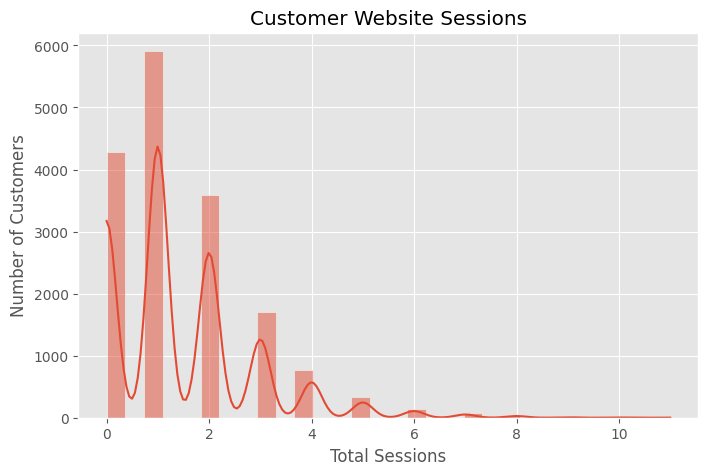

In [38]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="total_sessions",
    bins=30,
    kde=True
)

plt.title("Customer Website Sessions")
plt.xlabel("Total Sessions")
plt.ylabel("Number of Customers")
plt.show()

### Website revenue distribution:

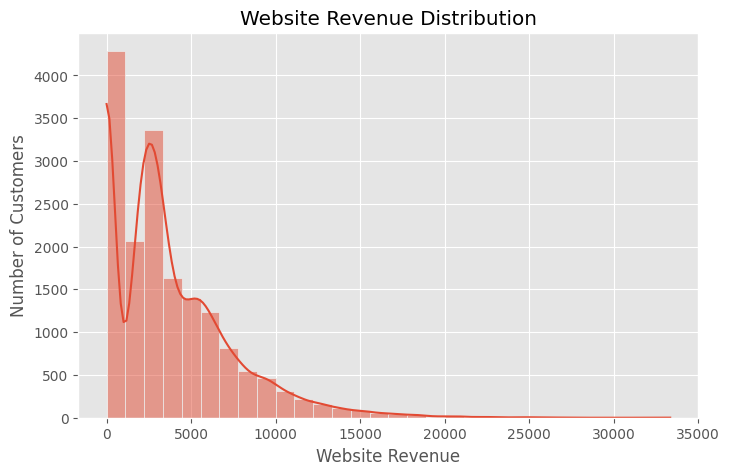

In [39]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="website_revenue",
    bins=30,
    kde=True
)

plt.title("Website Revenue Distribution")
plt.xlabel("Website Revenue")
plt.ylabel("Number of Customers")
plt.show()

### Preferred Device

#### Analyze whether customers primarily interact with the website through mobile,
#### desktop or other device categories.

In [40]:
device_counts=df["preferred_device"].value_counts()
device_counts

preferred_device
mobile     9171
Unknown    4285
desktop    3375
tablet       34
Name: count, dtype: int64

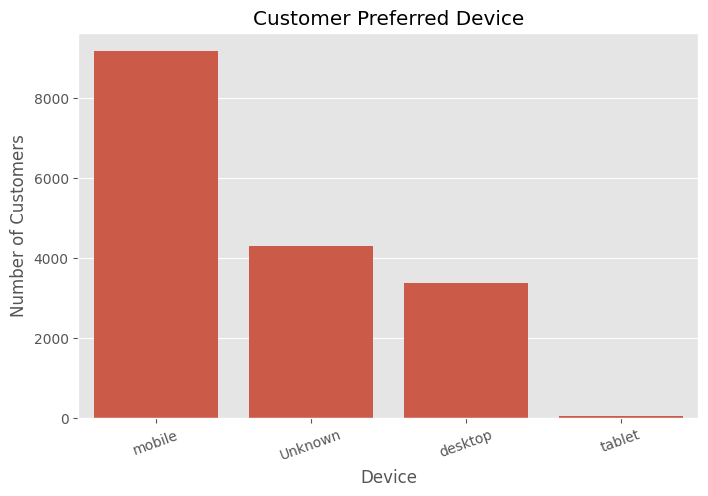

In [41]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="preferred_device",
    order=device_counts.index
)

plt.title("Customer Preferred Device")
plt.xlabel("Device")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.show()

### Preferred traffic source:

In [42]:
traffic_counts = (
    df["preferred_traffic_source"]
    .value_counts()
)
traffic_counts

preferred_traffic_source
Meta          6054
Unknown       4285
Google        2748
Influencer    2508
Email/SMS     1270
Name: count, dtype: int64

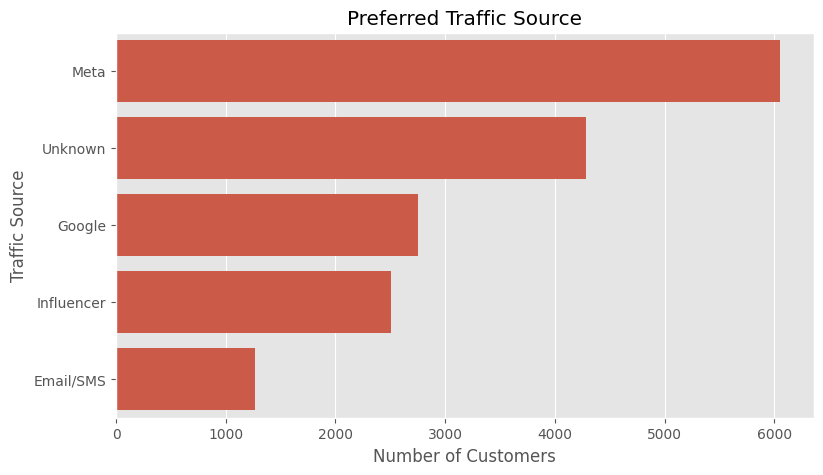

In [43]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    y="preferred_traffic_source",
    order=traffic_counts.index
)

plt.title("Preferred Traffic Source")
plt.xlabel("Number of Customers")
plt.ylabel("Traffic Source")
plt.show()

## Website conversions:

### Conversion Metrics

#### Analyze the customer journey from product viewing to cart addition,checkout and purchase.

In [44]:
conversion_columns = [
    "view_to_cart_rate",
    "cart_to_checkout_rate",
    "checkout_to_purchase_rate"
]
df[conversion_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
view_to_cart_rate,16865.0,0.280690,0.259572,0.0,0.0,0.25,0.375,3.0
cart_to_checkout_rate,16865.0,0.745924,0.435354,0.0,0.0,1.00,1.000,1.0
checkout_to_purchase_rate,16865.0,0.745924,0.435354,0.0,0.0,1.00,1.000,1.0


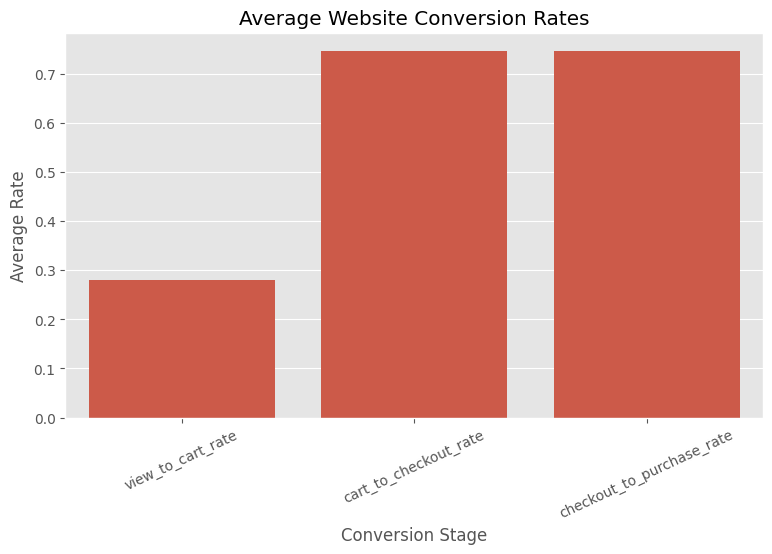

In [45]:
plt.figure(figsize=(9, 5))

conversion_means = df[conversion_columns].mean()

sns.barplot(
    x=conversion_means.index,
    y=conversion_means.values
)
plt.title("Average Website Conversion Rates")
plt.xlabel("Conversion Stage")
plt.ylabel("Average Rate")
plt.xticks(rotation=25)
plt.show()

### After examining the above visualizations, answer:

1. Which payment method is most preferred?
2. How many customers are repeat customers?
3. Which city/tier contributes the most revenue?
4. Which acquisition channel brings the most customers?
5. Which acquisition channel generates the most revenue?
6. Which product category is most preferred?
7. Is the customer return rate generally low or high?
8. Which device is most commonly preferred?
9. Which traffic source is most common?
10. At which website stage is the largest drop-off observed?


### Revenue and Order Behaviour

#### Analyze the relationship between customer spending and the number of orders.

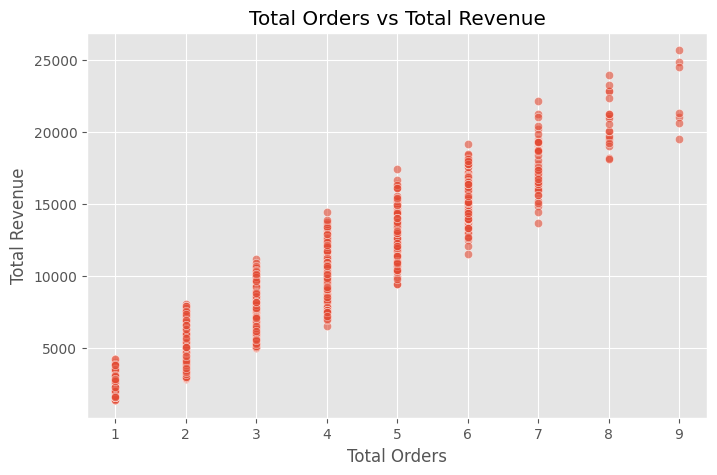

In [48]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="total_orders",
    y="total_revenue",
    alpha=0.6
)

plt.title("Total Orders vs Total Revenue")
plt.xlabel("Total Orders")
plt.ylabel("Total Revenue")
plt.show()

### Average Order Value vs Total Revenue

#### Check whether customers with higher average order values also generate higher total revenue.

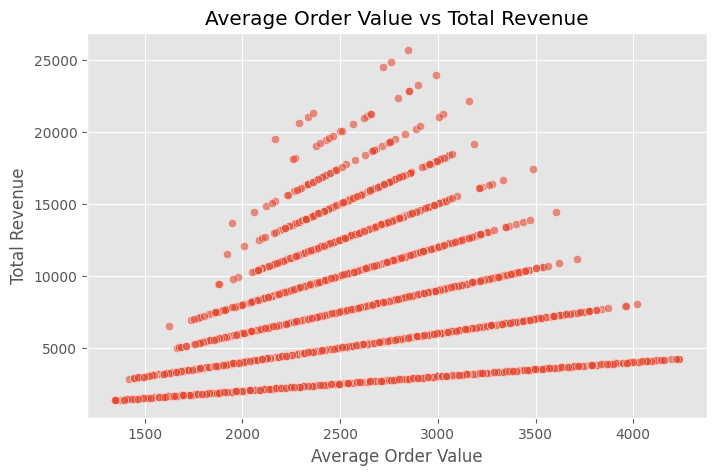

In [49]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="average_order_value",
    y="total_revenue",
    alpha=0.6
)

plt.title("Average Order Value vs Total Revenue")
plt.xlabel("Average Order Value")
plt.ylabel("Total Revenue")
plt.show()

### Website Engagement vs Revenue

#### Analyze whether highly engaged website customers generate more revenue.

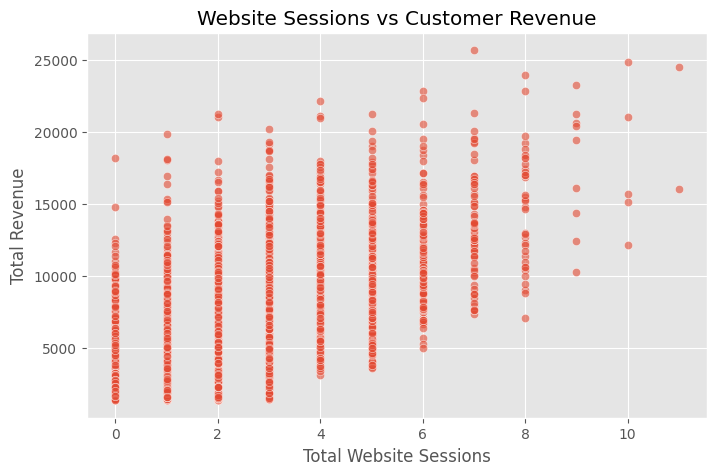

In [50]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="total_sessions",
    y="total_revenue",
    alpha=0.6
)

plt.title("Website Sessions vs Customer Revenue")
plt.xlabel("Total Website Sessions")
plt.ylabel("Total Revenue")
plt.show()

### Correlation Matrix

##### Correlation helps identify relationships between numerical features.

##### A value close to +1 indicates a strong positive relationship.
##### A value close to -1 indicates a strong negative relationship.
##### A value close to 0 indicates a weak linear relationship.

In [51]:
correlation=numerical.corr()
correlation.round(2)

,total_orders,total_revenue,average_order_value,time_to_2nd_purchase,repurchased,total_spend,avg_spend,median_spend,max_spend,min_spend,...,total_add_to_cart,total_checkout,total_purchases,website_revenue,view_to_cart_rate,cart_to_checkout_rate,checkout_to_purchase_rate,revenue_per_session,customer_lifetime_value,loyalty_score
total_orders,1.00,0.96,0.02,0.42,0.76,0.96,0.02,0.00,0.39,-0.36,...,0.64,0.64,0.64,0.62,0.15,0.29,0.29,0.27,0.96,0.94
total_revenue,0.96,1.00,0.26,0.41,0.73,1.00,0.26,0.25,0.59,-0.14,...,0.62,0.62,0.62,0.65,0.14,0.27,0.27,0.34,1.00,0.90
average_order_value,0.02,0.26,1.00,0.01,0.01,0.26,1.00,0.99,0.87,0.87,...,0.01,0.01,0.01,0.18,0.01,0.01,0.01,0.31,0.26,0.01
time_to_2nd_purchase,0.42,0.41,0.01,1.00,0.69,0.41,0.01,0.03,0.32,-0.34,...,0.27,0.27,0.27,0.27,0.11,0.20,0.20,0.19,0.41,0.32
repurchased,0.76,0.73,0.01,0.69,1.00,0.73,0.01,0.01,0.38,-0.37,...,0.49,0.49,0.49,0.48,0.18,0.31,0.31,0.29,0.73,0.63
total_spend,0.96,1.00,0.26,0.41,0.73,1.00,0.26,0.25,0.59,-0.14,...,0.62,0.62,0.62,0.65,0.14,0.27,0.27,0.34,1.00,0.90
avg_spend,0.02,0.26,1.00,0.01,0.01,0.26,1.00,0.99,0.87,0.87,...,0.01,0.01,0.01,0.18,0.01,0.01,0.01,0.31,0.26,0.01
median_spend,0.00,0.25,0.99,0.03,0.01,0.25,0.99,1.00,0.84,0.85,...,0.00,0.00,0.00,0.17,0.01,0.01,0.01,0.31,0.25,-0.00
max_spend,0.39,0.59,0.87,0.32,0.38,0.59,0.87,0.84,1.00,0.52,...,0.25,0.25,0.25,0.39,0.08,0.13,0.13,0.39,0.59,0.34
min_spend,-0.36,-0.14,0.87,-0.34,-0.37,-0.14,0.87,0.85,0.52,1.00,...,-0.23,-0.23,-0.23,-0.09,-0.06,-0.12,-0.12,0.15,-0.14,-0.32


### Correlation Heatmap:

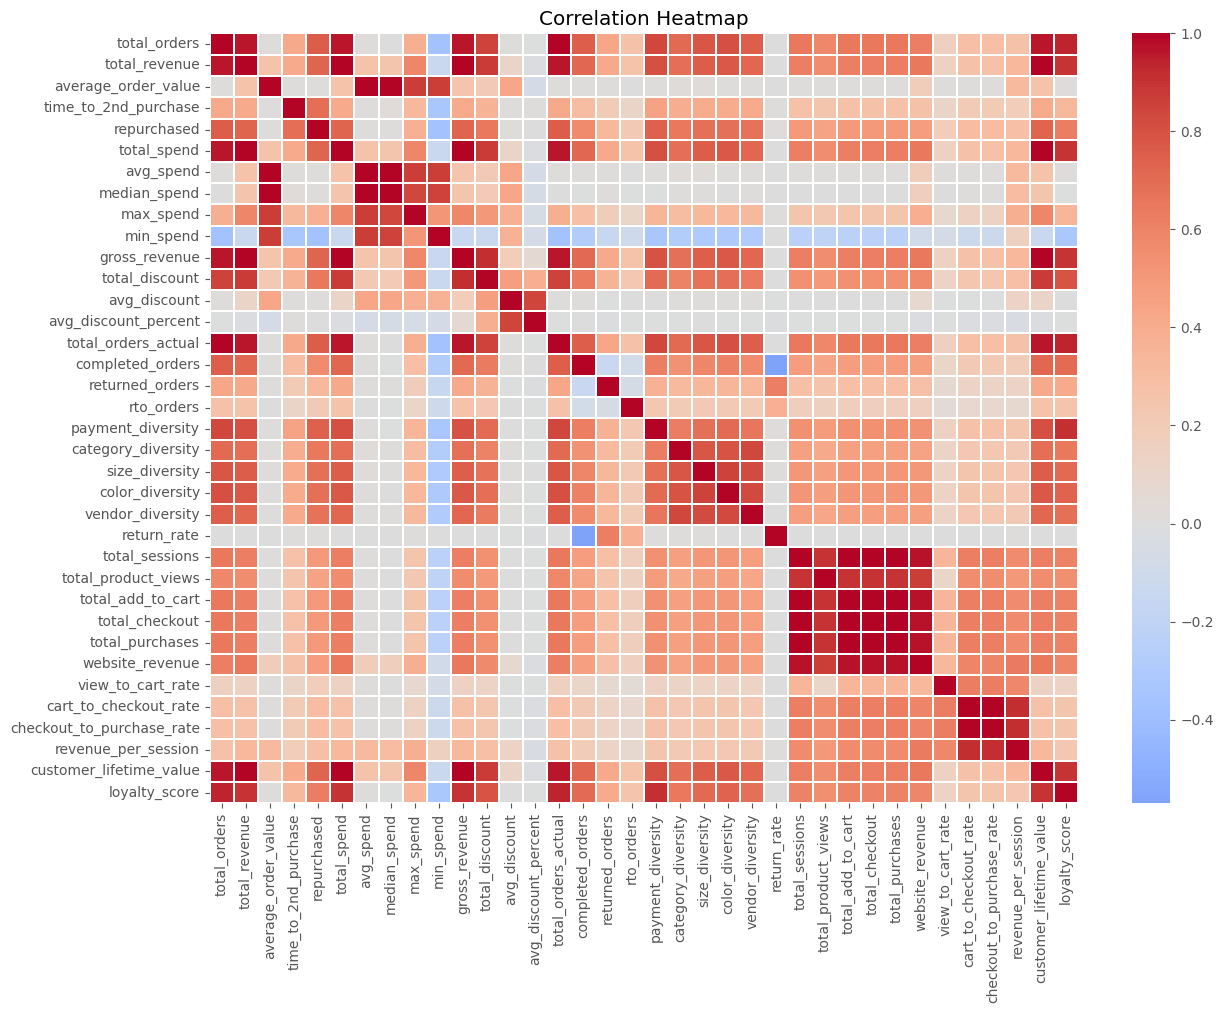

In [53]:
plt.figure(figsize=(14,10))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0,
    linewidths=0.3
)

plt.title("Correlation Heatmap")
plt.show()

### Strong Correlations:

In [54]:
corr_pairs=(
    correlation
    .where(np.triu(np.ones(correlation.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

corr_pairs.columns=[
    "Feature 1",
    "Feature 2",
    "Correlation"
]

strong_corr=(
    corr_pairs[
        corr_pairs["Correlation"].abs() >= 0.70
    ]
    .sort_values(
        "Correlation",
        key=lambda x: x.abs(),
        ascending=False
    )
)

strong_corr

,Feature 1,Feature 2,Correlation
13,total_orders,total_orders_actual,1.000000
38,total_revenue,total_spend,1.000000
620,cart_to_checkout_rate,checkout_to_purchase_rate,1.000000
594,total_checkout,total_purchases,1.000000
566,total_sessions,total_checkout,1.000000
...,...,...,...
18,total_orders,category_diversity,0.713093
403,total_orders_actual,category_diversity,0.713093
336,total_discount,payment_diversity,0.706974
439,completed_orders,loyalty_score,0.704710


## Outlier Analysis:

In [55]:
outlier_features=[
    "total_revenue",
    "average_order_value",
    "total_orders",
    "total_sessions",
    "customer_lifetime_value",
    "return_rate"
]

outlier_summary=[]

for col in outlier_features:
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)

    iqr= q3 - q1

    lower= q1-1.5*iqr
    upper= q3+1.5*iqr

    count=(
        (df[col] < lower) |
        (df[col] > upper)
    ).sum()

    outlier_summary.append({
        "Feature": col,
        "Lower Bound": lower,
        "Upper Bound": upper,
        "Outliers": count,
        "Outlier %": round(count/len(df)*100,2)
    })

outlier_summary=pd.DataFrame(outlier_summary)
outlier_summary

,Feature,Lower Bound,Upper Bound,Outliers,Outlier %
0,total_revenue,-2454.500,10573.500000,808,4.79
1,average_order_value,1065.675,3958.995000,94,0.56
2,total_orders,-0.500,3.500000,1322,7.84
3,total_sessions,-3.000,5.000000,266,1.58
4,customer_lifetime_value,-2454.500,10573.500000,808,4.79
5,return_rate,-1.000,1.666667,0,0.00


### Revenue Outliers:

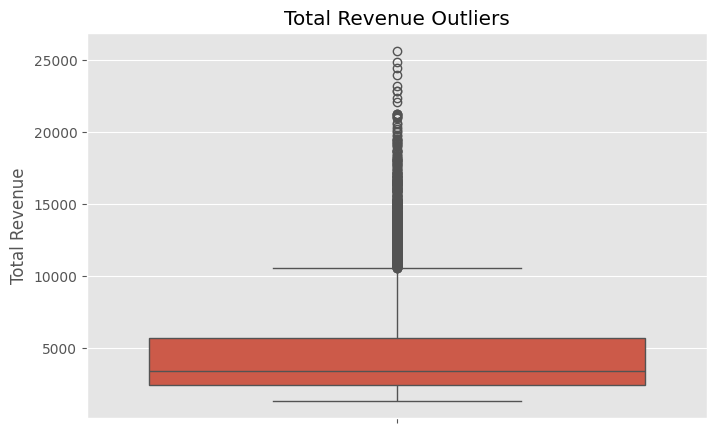

In [56]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    y="total_revenue"
)

plt.title("Total Revenue Outliers")
plt.ylabel("Total Revenue")

plt.show()

### Average order value outliers:

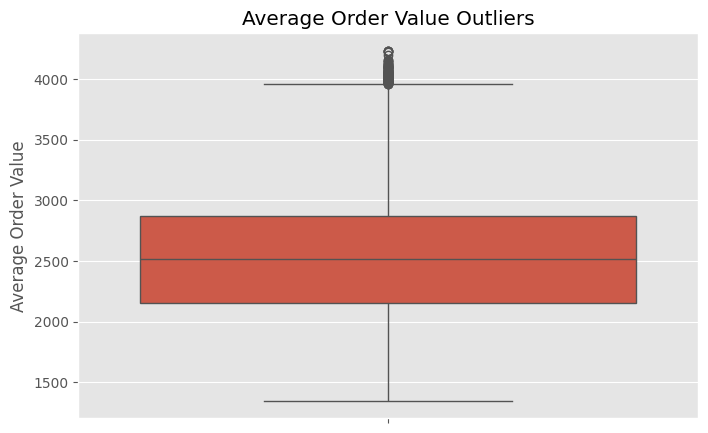

In [57]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    y="average_order_value"
)

plt.title("Average Order Value Outliers")
plt.ylabel("Average Order Value")
plt.show()

### Customer lifetime value outliers:

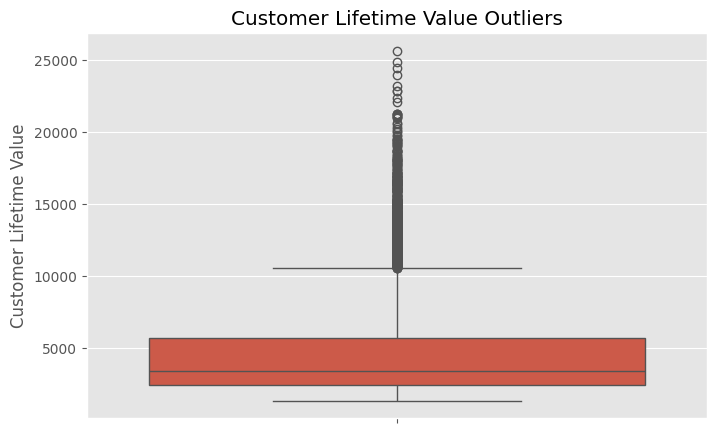

In [58]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    y="customer_lifetime_value"
)

plt.title("Customer Lifetime Value Outliers")
plt.ylabel("Customer Lifetime Value")
plt.show()

### Payment method vs Revenue:

In [59]:
payment_revenue=(
    df.groupby("preferred_payment")["total_revenue"]
    .agg(["count", "sum", "mean"])
    .sort_values("sum", ascending=False)
)

payment_revenue

,count,sum,mean
preferred_payment,,,
Card,5945,27656983.0,4652.141800
UPI,5398,23347959.0,4325.298073
COD,4065,20011412.0,4922.856581
NetBanking,867,3196618.0,3686.987313
Wallet,590,1794205.0,3041.025424


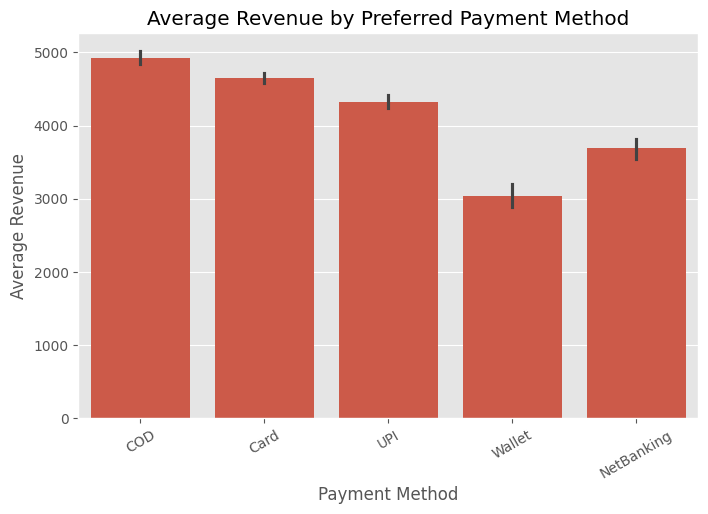

In [60]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="preferred_payment",
    y="total_revenue",
    estimator="mean"
)

plt.title("Average Revenue by Preferred Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Average Revenue")
plt.xticks(rotation=30)
plt.show()

### Repurchase behavior vs Revenue:

In [61]:
repurchase_revenue=(
    df.groupby("repurchased")["total_revenue"]
    .agg(["count", "sum", "mean"])
)

repurchase_revenue

,count,sum,mean
repurchased,,,
0,9117,22986827.0,2521.314797
1,7748,53020350.0,6843.101446


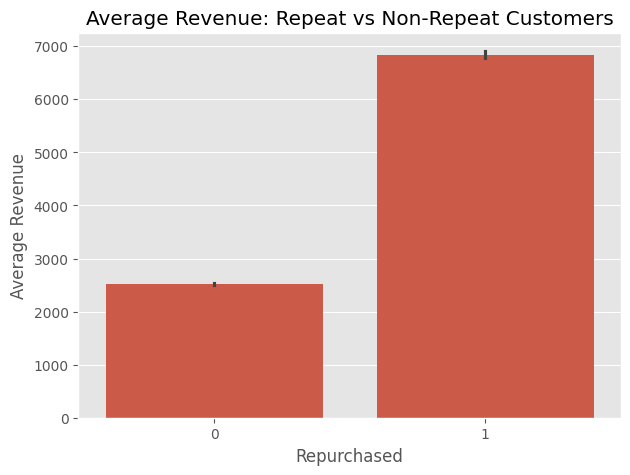

In [62]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x="repurchased",
    y="total_revenue",
    estimator="mean"
)

plt.title("Average Revenue: Repeat vs Non-Repeat Customers")
plt.xlabel("Repurchased")
plt.ylabel("Average Revenue")
plt.show()

### Website Conversion vs Customer Revenue:

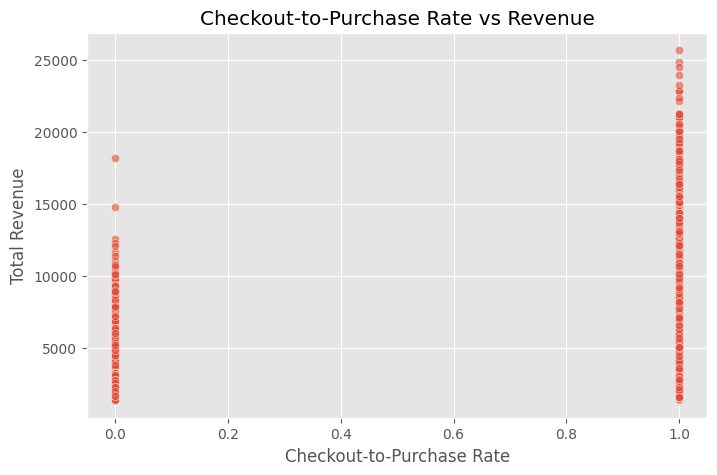

In [63]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="checkout_to_purchase_rate",
    y="total_revenue",
    alpha=0.6
)

plt.title("Checkout-to-Purchase Rate vs Revenue")
plt.xlabel("Checkout-to-Purchase Rate")
plt.ylabel("Total Revenue")
plt.show()

## Redundant Features

#### Some features may represent almost the same information.

##### For example:

##### - total_revenue and total_spend
##### - total_orders and total_orders_actual
##### - average_order_value and avg_spend
##### - customer_lifetime_value and total_revenue

In [64]:
redundant_pairs=strong_corr.copy()
redundant_pairs

,Feature 1,Feature 2,Correlation
13,total_orders,total_orders_actual,1.000000
38,total_revenue,total_spend,1.000000
620,cart_to_checkout_rate,checkout_to_purchase_rate,1.000000
594,total_checkout,total_purchases,1.000000
566,total_sessions,total_checkout,1.000000
...,...,...,...
18,total_orders,category_diversity,0.713093
403,total_orders_actual,category_diversity,0.713093
336,total_discount,payment_diversity,0.706974
439,completed_orders,loyalty_score,0.704710


### The following are candidate features for removal if they are strongly correlated
### with another feature carrying the same business meaning.

In [65]:
candidate_remove=[
    "total_spend",
    "avg_spend",
    "total_orders_actual"
]

candidate_remove

['total_spend', 'avg_spend', 'total_orders_actual']

### Create Numerical Clustering Candidate Dataset

#### Categorical features such as preferred payment, favorite category and device
#### will be handled separately in the clustering notebook.

In [66]:
clustering_candidates = [
    "total_orders",
    "total_revenue",
    "average_order_value",
    "median_spend",
    "max_spend",
    "total_discount",
    "avg_discount_percent",
    "completed_orders",
    "returned_orders",
    "rto_orders",
    "payment_diversity",
    "category_diversity",
    "size_diversity",
    "color_diversity",
    "vendor_diversity",
    "return_rate",
    "total_sessions",
    "total_product_views",
    "total_add_to_cart",
    "total_checkout",
    "total_purchases",
    "website_revenue",
    "view_to_cart_rate",
    "cart_to_checkout_rate",
    "checkout_to_purchase_rate",
    "revenue_per_session",
    "customer_lifetime_value",
    "loyalty_score"
]

clustering_df = df[
    ["customer_id"] + clustering_candidates
].copy()

clustering_df.head()

,customer_id,total_orders,total_revenue,average_order_value,median_spend,max_spend,total_discount,avg_discount_percent,completed_orders,returned_orders,...,total_add_to_cart,total_checkout,total_purchases,website_revenue,view_to_cart_rate,cart_to_checkout_rate,checkout_to_purchase_rate,revenue_per_session,customer_lifetime_value,loyalty_score
0,CUST-0000001,1,3356.0,3356.0,3356.0,3356,307,8.40,0,1,...,1.0,1.0,1.0,3356.0,0.250000,1.0,1.0,3356.0,3356.0,1
1,CUST-0000003,1,2360.0,2360.0,2360.0,2360,125,5.00,1,0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,2360.0,1
2,CUST-0000004,2,4029.0,2014.5,2014.5,2291,832,17.50,0,2,...,4.0,4.0,4.0,8058.0,0.363636,1.0,1.0,2014.5,4029.0,2
3,CUST-0000005,1,2581.0,2581.0,2581.0,2581,1003,28.00,1,0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,2581.0,1
4,CUST-0000007,2,5365.0,2682.5,2682.5,2994,1314,19.95,0,1,...,2.0,2.0,2.0,5365.0,0.500000,1.0,1.0,2682.5,5365.0,4


### Dataset summary:

In [67]:
print("Clustering Dataset Shape:", clustering_df.shape)
clustering_df.info()

Clustering Dataset Shape: (16865, 29)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16865 entries, 0 to 16864
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                16865 non-null  object 
 1   total_orders               16865 non-null  int64  
 2   total_revenue              16865 non-null  float64
 3   average_order_value        16865 non-null  float64
 4   median_spend               16865 non-null  float64
 5   max_spend                  16865 non-null  int64  
 6   total_discount             16865 non-null  int64  
 7   avg_discount_percent       16865 non-null  float64
 8   completed_orders           16865 non-null  int64  
 9   returned_orders            16865 non-null  int64  
 10  rto_orders                 16865 non-null  int64  
 11  payment_diversity          16865 non-null  int64  
 12  category_diversity         16865 non-null  int64  
 13  size_div

### Missing values check:

In [68]:
clustering_df.isnull().sum().sort_values(ascending=False).head(20)

customer_id             0
total_orders            0
total_revenue           0
average_order_value     0
median_spend            0
max_spend               0
total_discount          0
avg_discount_percent    0
completed_orders        0
returned_orders         0
rto_orders              0
payment_diversity       0
category_diversity      0
size_diversity          0
color_diversity         0
vendor_diversity        0
return_rate             0
total_sessions          0
total_product_views     0
total_add_to_cart       0
dtype: int64

In [69]:
clustering_df.to_csv(
    PROCESSED/"clustering_candidates.csv",
    index=False
)

## Notebook 05 – EDA Summary

The EDA identified:

- Customer spending patterns
- Payment preferences
- Repurchase behaviour
- Order outcomes
- City/tier distribution
- Acquisition channel performance
- Product preferences
- Return behaviour
- Website engagement
- Conversion behaviour
- Feature correlations
- Potential outliers
- Potentially redundant features

The cleaned numerical feature set has been saved as:
`clustering_candidates.csv`